<a href="https://colab.research.google.com/github/azzazyy/100-Days-of-python-bootcamp/blob/main/exercise_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision
## Exercise Sheet 1: Imaging
### Erhardt Barth / Christoph Linse / Manuel Laufer / Kathleen Anderson
Universität zu Lübeck, Institut für Neuro- und Bioinformatik

In case of questions, contact us via email: *{erhardt.barth, c.linse, m.laufer, k.anderson} @uni-luebeck.de*

## Note: Please insert the names of all participating students:

1. Azzazy Elassal
2. Amr Dorgham
3.
4.
5.


In [ ]:
import sys, os
if 'google.colab' in sys.modules:
  if os.getcwd() == '/content':
    !git clone 'https://github.com/inb-luebeck/cs4250.git'
    os.chdir('cs4250')

Cloning into 'cs4250'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 94 (delta 41), reused 68 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 1.26 MiB | 5.88 MiB/s, done.
Resolving deltas: 100% (41/41), done.


In [ ]:
import cv2 # open cv
import matplotlib.pyplot as plt # plotting tools
import numpy as np # matrix, array operations

from os.path import join # combine different items to a path
from os import getcwd, listdir # shows the current directory, lists items in a directory

# show plots when running cell
%matplotlib inline

## Exercise 1.1
### Loading and displaying images in Python
Download the image `clown.png` from the website of the tutorial. Load
the image in Python via opencv (`cv2.imread`). By default the image is loaded as BGR (blue, green, red), convert the image to gray with `cv2.cvtColor`.
Display the image `plt.imshow`, use the colormap `gray`.

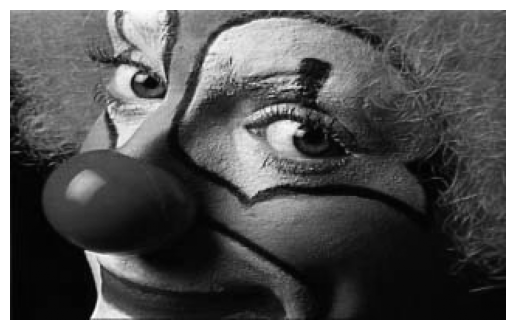

In [ ]:
# TODO: define image path
image_path = "/content/cs4250/data/exercise_1/clown.png"
# TODO: read image
image = cv2.imread(image_path)
# TODO: convert image to grayscale
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# TODO: display image
plt.imshow(image_gray, cmap='gray')
plt.axis('off')
plt.show()

## Exercise 1.2
### Image gradients
Images are stored as `numpy arrays`, for further computations convert the array to range $[0, 1]$ (`astype`). Define a function `load_gray_normalized` that loads the image, converts it to grayscale and normalizes it.
Compute the image gradients $d_x$ and $d_y$ for the image from the previous assignment. Initialize a simple gradient kernel like $[-1, 0, +1]$ for $d_x$ (`np.zeros`, `np.array`) and filter the image with it (`cv2.filter2D`). Visualize the results using `plt.imshow`. To this end, display the resulting images of both derivatives along `x` and `y` in a single figure (`plt.subplots`).

What do you need to take care of, to be able to visually **compare** the results?
Hint: the problem is related to the range of the pixel values in the two
gradient images. Name the problem and propose a solution to it by using the options of the `plt.imshow`
function.

In [ ]:
def load_gray_normalized(image_path):
  image = cv2.imread(image_path)
  image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  image_normalized = image_gray.astype('float32') / 255.0
  return image_normalized

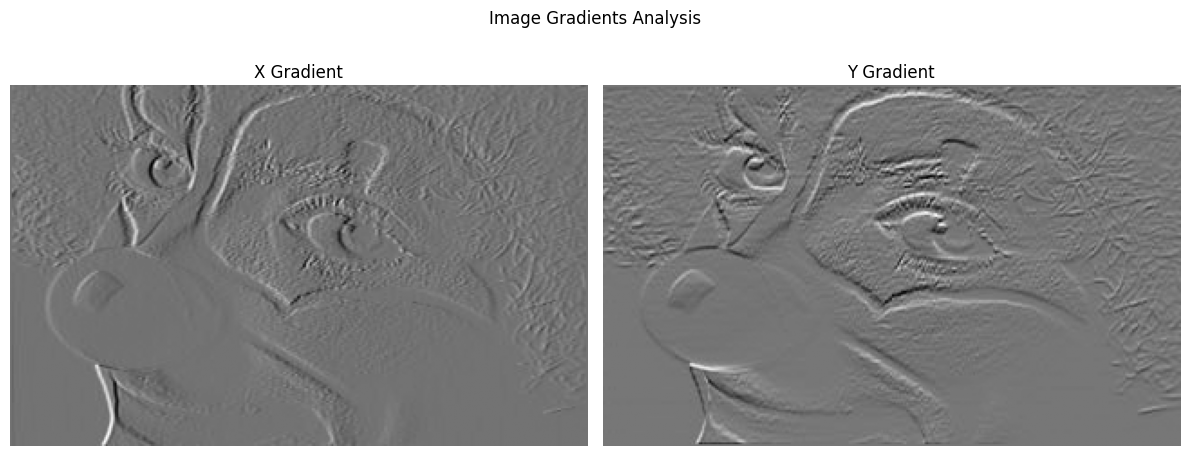

In [ ]:
# TODO: load image
norm_image = load_gray_normalized("/content/cs4250/data/exercise_1/clown.png")
# TODO: define kernels
dx_kernel = np.array([[-1,0,1]], dtype='float32')
dy_kernel = np.array([[-1],[0],[1]], dtype='float32')
# TODO: filter images
d_x = cv2.filter2D(norm_image, -1, dx_kernel)
d_y = cv2.filter2D(norm_image, -1, dy_kernel)
# TODO: display images
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(d_x, cmap='gray')
axes[0].set_title('X Gradient')
axes[0].axis('off')

axes[1].imshow(d_y, cmap='gray')
axes[1].set_title('Y Gradient')
axes[1].axis('off')

fig.suptitle('Image Gradients Analysis')
plt.tight_layout()
plt.show()

## Exercise 1.3
### Point operations
Download from the website the images `ueb131.png` and `ueb132.png`,
then load and display them.  
Both images illustrate two commonly encountered problems in photography.
Underexposed (overexposed) images are darker (brighter) than they should be,
because they have been exposed to too little (too much) light.

Compute and display the histograms (`plt.hist`,`np.flatten`) of the images in range $[0,1]$. Write a function `display_with_hist` that creates two subplots, showing the image and the respective histogram.

Can you identify the exposure problems in the histograms?
Hint: look at how the pixel intensities are distributed.

These defects can be corrected by remapping the pixel values to achieve a
more evenly distributed range of pixel intensities.
This can either be done by using histogram equalization (`cv2.equalizeHist`) or by using the logarithmic and power functions.

To use `cv2.equalizeHist`, the images need to be casted to uint8 in $[0,255]$. Write a function `normalized_to_uint8` to do this.

Apply the logarithmic and power to improve the two images. Experiment with different bases for the logarithm and power. To get a better feeling for the problem, plot the functions $x^2$ in $[0,1]$ and $log(x)$ in $[1,255]$ (why not $[0, 255]$?, `np.linspace, np.log, plt.plot`). **Where do the functions change quickly, where do they change slowly? How can you use this knowledge to improve the images?**

In [ ]:
def display_with_hist(image , title):

    img_normalized = image.astype('float32') / 255.0
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(img_normalized, cmap='gray', vmin=0.0, vmax=1.0)
    axes[0].set_title(f"{title}")
    axes[0].axis('off')

    axes[1].hist(img_normalized.flatten(), bins=256, range=(0.0, 1.0), color='blue', alpha=0.5)
    axes[1].set_title(f"{title} Histogram")
    axes[1].set_xlabel("Intensity Value")
    axes[1].set_ylabel("Pixel Count")

    fig.suptitle(f"{title} Histogram Analysis")
    plt.tight_layout()
    plt.show()




In [ ]:
def normalized_to_uint8(image):
    img_scaled = image* 255.0
    img_uint8 = img_scaled.astype('uint8')
    return img_uint8

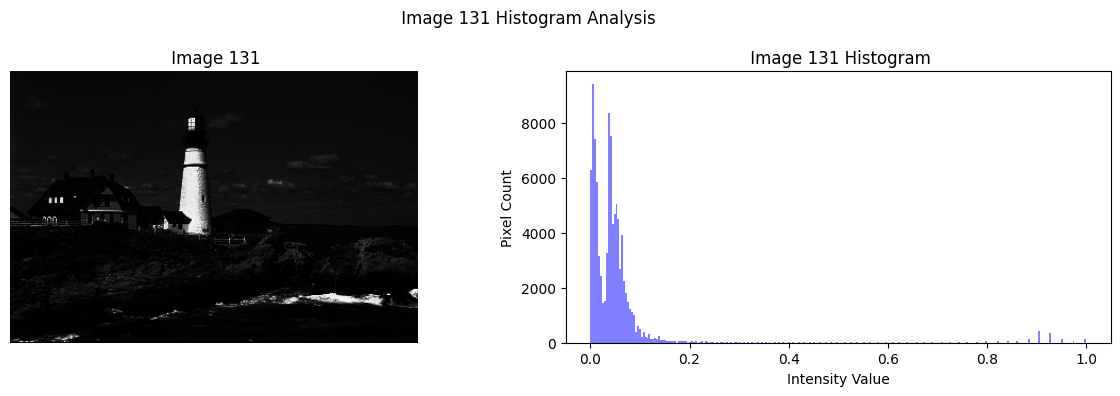

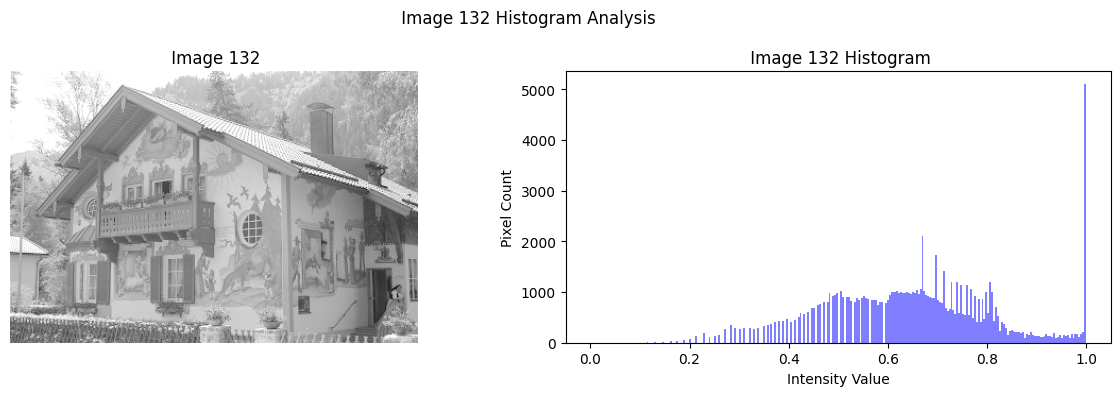

In [ ]:
# TODO: load images
ueb131 = cv2.imread("/content/cs4250/data/exercise_1/ueb131.png", cv2.IMREAD_GRAYSCALE)
ueb132 = cv2.imread("/content/cs4250/data/exercise_1/ueb132.png", cv2.IMREAD_GRAYSCALE)
# TODO: display images with histograms
display_with_hist(ueb131 , " Image 131")
display_with_hist(ueb132 , " Image 132")

In [ ]:
# TODO: convert images to uint8
ueb131_normalized = ueb131.astype('float32') / 255.0
ueb132_normalized = ueb132.astype('float32') / 255.0
uint8_131 = normalized_to_uint8(ueb131_normalized)
uint8_132 = normalized_to_uint8(ueb132_normalized)
ueb131_equ = cv2.equalizeHist(uint8_131)
ueb132_equ = cv2.equalizeHist(uint8_132)
# TODO: display images with histograms
display_with_hist(ueb131_equ , " Image 131 Equalized")
display_with_hist(ueb132_equ , " Image 132 Equalized")

In [ ]:
# TODO: display logarithmic function
x_log = np.linspace(1, 255, 100)
y_log = np.log(x_log)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(x_log, y_log, color='green', linewidth=2)
plt.title("Logarithmic Function log(x)")
plt.xlabel("Input Pixels [1, 255]")
plt.ylabel("Output")

# TODO: display quadratic function
x_quad = np.linspace(0, 1, 100)
y_quad = x_quad ** 2

plt.subplot(1, 2, 2)
plt.plot(x_quad, y_quad, color='red', linewidth=2)
plt.title("Quadratic Function x^2")
plt.xlabel("Input Pixels [0, 1]")
plt.ylabel("Output")

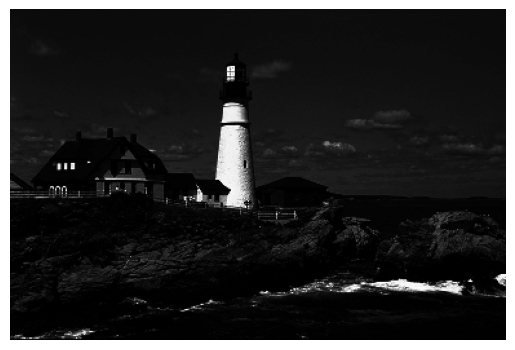

In [ ]:
# TODO: transform and display ueb131.png
img_log_transformed = np.log(ueb131_normalized + 1.0) / np.log(2.0)
plt.imshow(img_log_transformed, cmap='gray', vmin=0.0, vmax=1.0)
plt.axis('off')
plt.show()


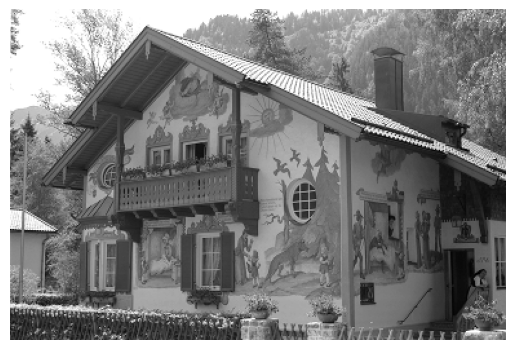

In [ ]:
# TODO: transform and display ueb132.png
img_quad_transformed = ueb132_normalized ** 2
plt.imshow(img_quad_transformed, cmap='gray', vmin=0.0, vmax=1.0)
plt.axis('off')
plt.show()
